# EDA de MODIS MAIAC sobre Cali

MODIS es un par de sensores en los satélites Terra y Aqua, y el producto MCD19A2 sale de un algoritmo llamado MAIAC que estima cada día el espesor óptico de aerosoles, o AOD. El AOD no es contaminación medida en el aire que respiramos: es qué tanto la columna entera de atmósfera, desde el suelo hasta el tope, atenúa la luz del sol por culpa de las partículas en suspensión. Por eso se usa como proxy de material particulado (PM): cuando hay más humo, polvo o aerosol urbano, el AOD sube. Es la única fuente del panel que mira los aerosoles, así que aporta una pista de PM que ni Sentinel-5P ni Sentinel-2 cubren.

Para Cali trabajamos con dos capas por escena, ambas a 1 kilómetro: la banda verde del AOD (**Optical_Depth_055**, la que el equipo docente fijó como estándar de PM) y la máscara de calidad (**AOD_QA**), que es un entero de 16 bits donde cada grupo de bits cuenta algo distinto sobre el píxel. El dato llega como entero, así que el AOD físico sale de multiplicar por 0,001.

Hay un punto que marca todo el análisis y conviene decirlo desde el arranque: MAIAC solo recupera AOD cuando el cielo está despejado, y Cali tiene clima Af, tropical húmedo, con nube casi todo el año. El resultado es que la mayoría de los píxeles vienen vacíos. Buena parte de este EDA consiste en medir ese vacío con cuidado, separar lo que es física de la nube de lo que sería un error, y decidir cómo se usa un dato tan hueco en las fases siguientes.

## Preparación

Dejamos el entorno listo antes de tocar los rasters: herramientas, estilo, dónde están los datos, las constantes del dominio y las funciones que se repiten.

### *Importación de dependencias*

In [1]:
import os
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
import rasterio
from rasterio.windows import from_bounds

### *Estilo de las gráficas y semilla*

In [2]:
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

SEED = 137
rng = np.random.default_rng(SEED)

### *Ubicación de los datos*

In [3]:
def _buscar_datos():
    env = os.environ.get("MAIAC_L2")
    if env and Path(env).exists():
        return Path(env)
    for base in [Path.cwd(), *Path.cwd().parents]:
        cand = base / "data" / "maiac" / "l2"
        if cand.exists():
            return cand
    raise FileNotFoundError("No encuentro data/maiac/l2 desde el directorio actual")


L2 = _buscar_datos()
print("Datos MAIAC:", L2)

Datos MAIAC: C:\Users\mitgar14\Desktop\Ingenieria de Datos e IA - UAO\Semestre 7\Analítica\Semana #12 - #17\Proyecto\data\maiac\l2


### *Constantes del dominio*

In [4]:
# La descarga cubre un rectángulo amplio del Valle del Cauca, no solo Cali. Eso evita
# perder cobertura por las órbitas que rozan el borde, pero mete mucha cordillera.
BBOX_VALLE = (-77.0, 3.0, -75.8, 5.0)   # lonmin, latmin, lonmax, latmax
BBOX_CALI = (-76.60, 3.30, -76.40, 3.55)

# El AOD llega como entero con factor de escala; el AOD_QA es un bit-field de 16 bits.
FILL = -32768
SCALE = 0.001
PERIODO = (date(2020, 1, 1), date(2024, 12, 31))

# Periodo afectado por la anomalía LDOPE HC_MCD19_24226 (coeficientes mal inicializados).
ANOMALIA_2022 = (date(2022, 1, 1), date(2022, 7, 2))

# Las nueve estaciones de DAGMA (lon, lat), la referencia de suelo del proyecto.
ESTACIONES = {
    "Base Aérea": (-76.50653649, 3.45731978),
    "ERA Obrero": (-76.51908184, 3.44759410),
    "Cañaveralejo": (-76.54961789, 3.41545841),
    "Univalle": (-76.53372474, 3.37796681),
    "Pance": (-76.53125401, 3.30449556),
    "Transitoria": (-76.49495633, 3.41717874),
    "Compartir": (-76.46657547, 3.42825808),
    "La Flora": (-76.51805771, 3.48822548),
    "La Ermita": (-76.53097834, 3.45551754),
}

MESES = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]

### *Funciones de apoyo*

In [5]:
def fmt(n, dec=0):
    """Número al estilo local: punto para miles, coma para decimales."""
    s = f"{n:,.{dec}f}"
    return s.replace(",", "X").replace(".", ",").replace("X", ".")


def listar():
    """Lista ordenada de (fecha, ruta) de cada MCD19A2.tif bajo l2/YYYY/MM/DD/."""
    filas = []
    for p in sorted(L2.rglob("MCD19A2.tif")):
        y, m, d = int(p.parts[-4]), int(p.parts[-3]), int(p.parts[-2])
        filas.append((date(y, m, d), p))
    return filas


def leer(path):
    """Abre una escena y devuelve el AOD crudo (int16) y el AOD_QA como entero sin signo."""
    with rasterio.open(path) as src:
        aod = src.read(1).astype(np.int16)
        qa = src.read(2).astype(np.int32) & 0xFFFF  # toInt16 guardó el bit-field con signo
        return aod, qa, src.transform, src.bounds


def cobertura_cali(arr, transform):
    """Recorta el arreglo al recuadro de Cali usando la georreferencia de la escena."""
    win = from_bounds(*BBOX_CALI, transform=transform)
    r0, c0 = max(int(round(win.row_off)), 0), max(int(round(win.col_off)), 0)
    r1 = min(r0 + int(round(win.height)), arr.shape[0])
    c1 = min(c0 + int(round(win.width)), arr.shape[1])
    return arr[r0:r1, c0:c1]

Sobre el bit-field hay que decir algo antes de usarlo. El `AOD_QA` empaqueta varios campos dentro de un entero de 16 bits, y cada campo se lee desplazando y enmascarando bits. Los dos que nos importan son la máscara de nube, en los tres bits más bajos, y la calidad del AOD, en los bits 8 a 11:

$$\text{nube} = \text{QA} \mathbin{\&} \text{0b111} \qquad \text{calidad} = (\text{QA} \gg 8) \mathbin{\&} \text{0b1111}$$

El campo de nube vale 1 cuando el píxel es despejado (Clear) y 2 cuando es posiblemente nuboso. El campo de calidad vale 0 cuando el retrieval es el mejor posible (Best Quality). El símbolo $\&$ es el "y" bit a bit y $\gg$ corre los bits a la derecha, que es la forma estándar de sacar un campo escondido dentro de un entero.

In [6]:
def decodificar(qa):
    """Saca del bit-field el campo de nube (bits 0 a 2) y el de calidad del AOD (bits 8 a 11)."""
    nube = qa & 0b111
    calidad = (qa >> 8) & 0b1111
    return nube, calidad

## 1. Qué tenemos en la mano

Cada día con dato es un GeoTIFF chiquito guardado en una carpeta con forma `l2/año/mes/día/`. Sin abrir las imágenes, recorremos esas carpetas y armamos la lista completa de fechas. Lo primero que queremos saber es cuántos días de los cinco años llegaron con algún dato y cómo se reparten por año, porque MAIAC se descarga a diario pero los días totalmente tapados por nube ni siquiera se guardan.

Escenas con dato:   1.584
Días del periodo:   1.827 (2020-01-01 a 2024-12-31)
Días sin nada:      243 (13,3%)


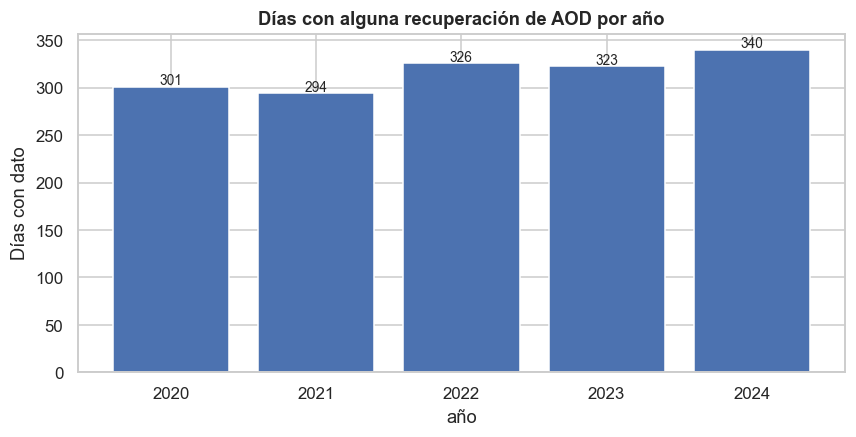

In [7]:
tifs = listar()
inv = pd.DataFrame({"fecha": [f for f, _ in tifs]})
inv["anio"] = inv["fecha"].apply(lambda d: d.year)

dias_periodo = (PERIODO[1] - PERIODO[0]).days + 1
print(f"Escenas con dato:   {fmt(len(inv))}")
print(f"Días del periodo:   {fmt(dias_periodo)} ({PERIODO[0]} a {PERIODO[1]})")
print(f"Días sin nada:      {fmt(dias_periodo - len(inv))} ({fmt(100 * (dias_periodo - len(inv)) / dias_periodo, 1)}%)")

fig, ax = plt.subplots(figsize=(9, 4))
conteo = inv["anio"].value_counts().sort_index()
ax.bar(conteo.index.astype(str), conteo.values, color="#4c72b0", edgecolor="white")
for i, v in enumerate(conteo.values):
    ax.text(i, v + 2, fmt(v), ha="center", fontsize=9)
ax.set_ylabel("Días con dato"); ax.set_xlabel("año")
ax.set_title("Días con alguna recuperación de AOD por año")
plt.show()

De los 1.827 días del periodo, llegaron 1.584 con al menos un píxel de AOD, o sea cerca del 87%. Los otros 243 días quedaron completamente tapados y no dejaron rastro. El reparto por año sube despacio, de 301 días en 2020 a 340 en 2024, sin saltos raros que delaten un problema de descarga. Hasta aquí parece un dato sano; el hueco grande no está en los días, sino dentro de cada escena, como se ve enseguida.

## 2. Dónde aterriza el dato

Antes de mirar valores, recorremos las escenas una por una y, por cada píxel del mapa, contamos cuántas veces llegó a tener AOD válido en los cinco años. Ese conteo dibuja un mapa de disponibilidad: dónde el satélite logra ver el suelo seguido y dónde casi nunca. De paso resumimos cada escena en una fila, con cuánto de su área quedó con dato sobre el rectángulo amplio del Valle y sobre el recuadro estrecho de Cali.

In [8]:
filas = []
freq = None
n_modal = 0
muestra_aod = []
for fecha, path in tifs:
    aod, qa, transform, bounds = leer(path)
    if freq is None:
        ref_shape, ref_bounds = aod.shape, bounds
        freq = np.zeros(ref_shape, dtype=np.int32)
    valido = aod != FILL
    nv, size = int(valido.sum()), aod.size
    nube, calidad = decodificar(qa)
    clear = valido & (nube == 1)
    best = clear & (calidad == 0)
    relajado = valido & ((nube == 1) | (nube == 2))
    val_cali = cobertura_cali(aod, transform) != FILL
    if aod.shape == ref_shape:
        freq += valido
        n_modal += 1
    fila = {
        "fecha": fecha, "anio": fecha.year, "mes": fecha.month,
        "pct_valle": 100 * nv / size,
        "pct_cali": 100 * val_cali.mean() if val_cali.size else np.nan,
        "pct_clear": 100 * int(clear.sum()) / size,
        "pct_best": 100 * int(best.sum()) / size,
        "pct_relajado": 100 * int(relajado.sum()) / size,
    }
    if nv > 0:
        av = aod[valido].astype(np.float64) * SCALE
        fila.update(aod_mediana=float(np.median(av)), aod_media=float(av.mean()),
                    aod_p95=float(np.percentile(av, 95)), aod_max=float(av.max()),
                    aod_min=float(av.min()))
        if len(muestra_aod) < 80:
            muestra_aod.append(av[::5])
    filas.append(fila)
esc = pd.DataFrame(filas)
freq_pct = 100 * freq / max(n_modal, 1)

print(f"Cobertura de píxel por escena (mediana):  Valle {fmt(esc.pct_valle.median(), 1)}%   Cali {fmt(esc.pct_cali.median(), 1)}%")
print(f"Cobertura de píxel por escena (media):    Valle {fmt(esc.pct_valle.mean(), 1)}%   Cali {fmt(esc.pct_cali.mean(), 1)}%")

Cobertura de píxel por escena (mediana):  Valle 4,8%   Cali 4,2%
Cobertura de píxel por escena (media):    Valle 8,9%   Cali 17,4%


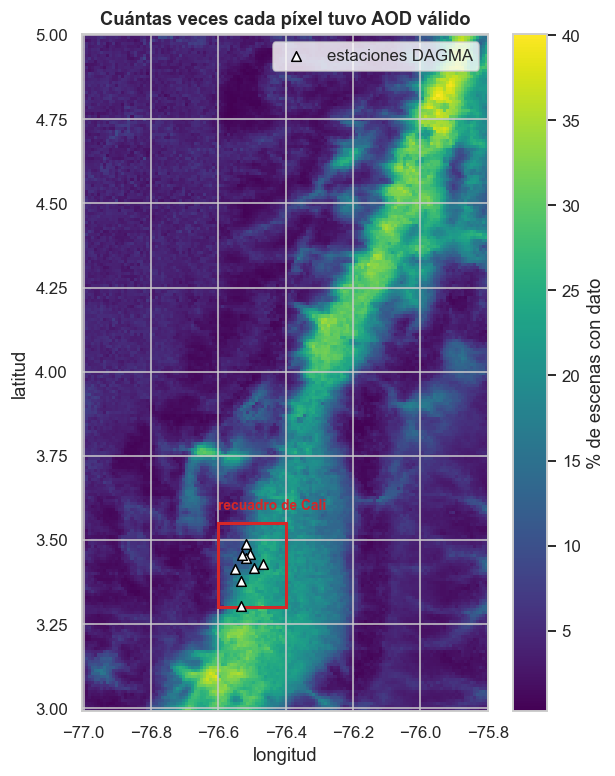

In [9]:
oeste, sur, este, norte = ref_bounds.left, ref_bounds.bottom, ref_bounds.right, ref_bounds.top
fig, ax = plt.subplots(figsize=(6, 8))
im = ax.imshow(freq_pct, cmap="viridis", extent=[oeste, este, sur, norte], origin="upper")
ax.add_patch(Rectangle((BBOX_CALI[0], BBOX_CALI[1]), BBOX_CALI[2] - BBOX_CALI[0],
                       BBOX_CALI[3] - BBOX_CALI[1], fill=False, edgecolor="#d62728", lw=2))
ax.text(BBOX_CALI[0], BBOX_CALI[3] + 0.04, "recuadro de Cali", color="#d62728", fontsize=9, weight="bold")
ex = list(ESTACIONES.values())
ax.scatter([e[0] for e in ex], [e[1] for e in ex], marker="^", c="white",
           edgecolors="black", s=40, zorder=5, label="estaciones DAGMA")
ax.set_xlabel("longitud"); ax.set_ylabel("latitud")
ax.set_title("Cuántas veces cada píxel tuvo AOD válido")
ax.legend(loc="upper right")
plt.colorbar(im, ax=ax, label="% de escenas con dato")
plt.show()

El mapa termina dibujando la geografía del Valle del Cauca. La banda central, más clara, que corre de sur a norte, es el valle plano del río Cauca, donde el satélite logra ver el suelo entre el 20 y el 40% de los días. A los lados, en azul oscuro, están las laderas de las cordilleras Occidental y Central, que casi nunca dejan dato porque acumulan más nube orográfica y tienen terreno más quebrado. El recuadro de Cali cae sobre la parte ancha del valle, junto con las nueve estaciones de DAGMA, así que está en la zona de mejor cobertura del rectángulo. Por eso, en promedio, el recuadro de Cali recupera cerca del doble de dato que el Valle completo (17% frente a 9%): el rectángulo amplio arrastra hacia abajo toda esa cordillera sin dato.

## 3. Cuándo hay dato

La cobertura no solo cambia en el espacio, también en el calendario. Como la nube es la que manda, conviene ver si hay temporadas mejores y peores. Un mapa de calor del porcentaje de píxeles válidos por mes y año muestra el patrón estacional, y de paso si algún año se sale de la norma.

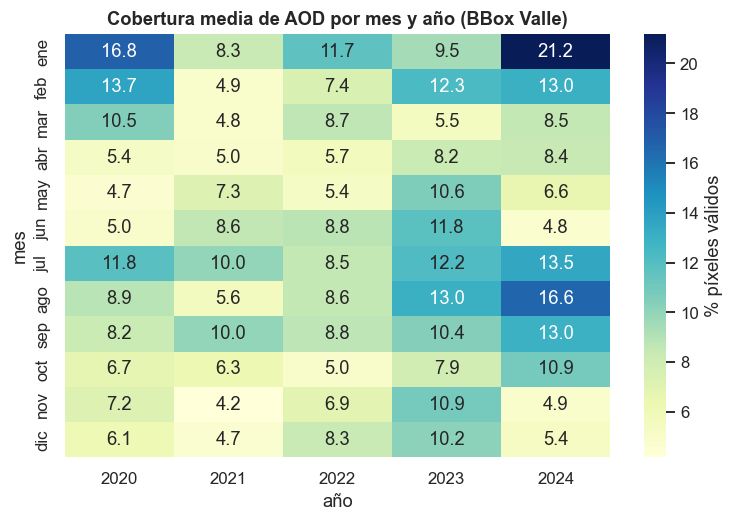

Meses con mejor cobertura: ene 13,6%, jul 11,2%, ago 10,7%
Meses con peor cobertura:  abr 6,7%, nov 6,8%, mar 7,7%


In [10]:
piv = esc.pivot_table(index="mes", columns="anio", values="pct_valle", aggfunc="mean")
piv = piv.reindex(range(1, 13))
piv.index = MESES

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(piv, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "% píxeles válidos"})
ax.set_title("Cobertura media de AOD por mes y año (BBox Valle)")
ax.set_xlabel("año"); ax.set_ylabel("mes")
plt.show()

por_mes = esc.groupby("mes")["pct_valle"].mean()
secos = ", ".join(f"{MESES[m-1]} {fmt(por_mes[m], 1)}%" for m in [1, 7, 8])
lluvia = ", ".join(f"{MESES[m-1]} {fmt(por_mes[m], 1)}%" for m in [4, 11, 3])
print(f"Meses con mejor cobertura: {secos}")
print(f"Meses con peor cobertura:  {lluvia}")

El patrón sigue el régimen de lluvia bimodal del Valle. Los meses más secos, enero y la mitad del año (julio y agosto), traen la mejor cobertura, cerca del 11 al 14%. Las dos temporadas de lluvia, marzo a mayo y octubre a noviembre, la hunden hasta el 7%. La diferencia confirma que el vacío es de la nube y no del sensor: cuando llueve menos, hay más cielo despejado y más AOD recuperado. No hay un año que se dispare en cobertura, aunque la magnitud del AOD de comienzos de 2022 merece una mirada aparte más adelante.

## 4. Del entero crudo al AOD

El número que trae cada píxel no es el AOD todavía, es un entero que hay que escalar. La cuenta es directa:

$$\text{AOD} = \text{DN} \times 0{,}001$$

donde $\text{DN}$ es el entero guardado en el píxel. El valor -32.768 está reservado para "sin dato", así que se saca antes de escalar. El AOD es adimensional y, sobre una ciudad, suele moverse entre cerca de 0 (aire limpio) y cerca de 1 (mucho aerosol); valores más altos son episodios fuertes de humo o polvo.

In [11]:
ej_fecha = esc.loc[esc["pct_valle"].idxmax(), "fecha"]
ej_path = dict(tifs)[ej_fecha]
aod_ej, qa_ej, _, _ = leer(ej_path)
crudo = aod_ej[aod_ej != FILL]
fisico = crudo.astype(np.float64) * SCALE
print(f"Escena más despejada: {ej_fecha}")
print(f"AOD crudo (entero):  media = {fmt(crudo.mean(), 1)}")
print(f"AOD físico:          media = {fmt(fisico.mean(), 3)}, máximo = {fmt(fisico.max(), 3)}")

Escena más despejada: 2024-08-30
AOD crudo (entero):  media = 74,7
AOD físico:          media = 0,075, máximo = 0,527


Sobre la escena más despejada de los cinco años, la del 30 de agosto de 2024, el entero medio queda cerca de 75 y, al multiplicarlo por 0,001, da un AOD medio cerca de 0,075. Es un valor bajo, coherente con que la escena con más cielo limpio es también la de menos aerosol. Ningún valor sale negativo ni absurdo, así que el factor de escala y el descarte del relleno están bien aplicados. Con la conversión clara, ya se puede mirar la calidad de cada píxel.

## 5. La máscara de calidad y el peso de los nulos

No todos los píxeles con AOD valen lo mismo: el `AOD_QA` distingue los que vienen de cielo despejado de los que tienen nube cerca, y dentro de esos marca cuáles son de la mejor calidad. La pregunta práctica es cuánto dato queda tras cada filtro. Comparamos tres políticas sobre cada escena: la más estricta (Best Quality), la de solo cielo despejado (Clear) y una relajada que además admite píxeles posiblemente nubosos.

Cobertura media por escena según el filtro (BBox Valle):
  Cualquier AOD recuperado:   8,9%
  Solo despejado (Clear):     8,9%
  Mejor calidad (Best):       3,1%
  Relajado (incluye dudosos): 8,9%

De los píxeles con AOD, son Best Quality: 35,1%


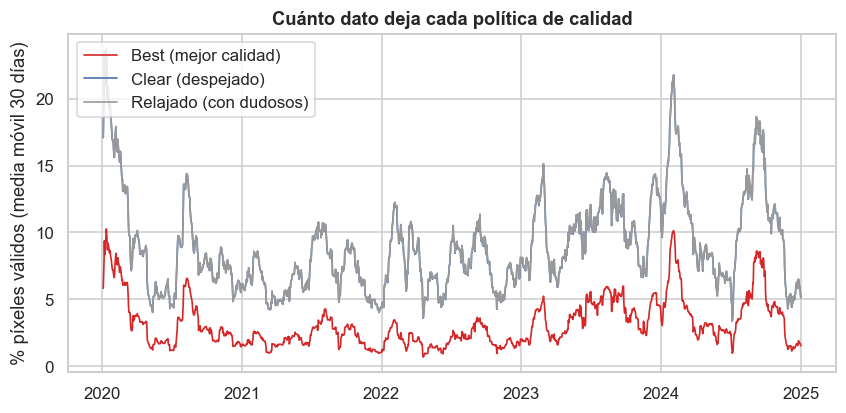

In [12]:
print("Cobertura media por escena según el filtro (BBox Valle):")
print(f"  Cualquier AOD recuperado:   {fmt(esc.pct_valle.mean(), 1)}%")
print(f"  Solo despejado (Clear):     {fmt(esc.pct_clear.mean(), 1)}%")
print(f"  Mejor calidad (Best):       {fmt(esc.pct_best.mean(), 1)}%")
print(f"  Relajado (incluye dudosos): {fmt(esc.pct_relajado.mean(), 1)}%")
frac_best = 100 * esc.pct_best.sum() / esc.pct_valle.sum()
print(f"\nDe los píxeles con AOD, son Best Quality: {fmt(frac_best, 1)}%")

fig, ax = plt.subplots(figsize=(9, 4))
orden = ["pct_best", "pct_clear", "pct_relajado"]
etiquetas = ["Best (mejor calidad)", "Clear (despejado)", "Relajado (con dudosos)"]
colores = ["#d62728", "#4c72b0", "#999999"]
for col, et, c in zip(orden, etiquetas, colores):
    serie = esc.set_index("fecha")[col].rolling(30, min_periods=5).mean()
    ax.plot(serie.index, serie.values, lw=1.1, color=c, label=et)
ax.set_ylabel("% píxeles válidos (media móvil 30 días)")
ax.set_title("Cuánto dato deja cada política de calidad")
ax.legend(loc="upper left")
plt.show()

El recorte que impone cada filtro es muy distinto. Quedarse solo con la mejor calidad deja una cobertura cerca del 3% del rectángulo, porque apenas un tercio de los píxeles con AOD, cerca del 35%, alcanza ese grado. La política de cielo despejado, en cambio, recupera casi todo lo que hay: su cobertura coincide con la de cualquier AOD recuperado, lo que dice que casi todos los retrievals ya vienen marcados como despejados. La nube no deja un retrieval malo, deja un hueco. La relajada no suma nada. La lectura para el proyecto es directa: exigir Best Quality sería botar la mayor parte del dato, así que el filtro razonable en este clima es quedarse con todos los píxeles despejados y no pedir más. Aun así, hablamos de una cobertura del orden del 9% sobre el Valle y del 17% sobre Cali, es decir entre el 83 y el 91% de nulos. No es un error de descarga: es lo que un sensor pasivo logra ver bajo el cielo de Cali.

## 6. Cuánto aerosol hay

Dejando de lado el hueco, miramos qué valores toma el AOD que sí se recupera, porque es lo que entraría al modelo. Juntamos el AOD válido de muchas escenas y miramos su distribución, para compararla con lo que reporta la literatura de la región andina.

AOD mediano (mediana de medianas por escena): 0,224
AOD máximo global:                            5,508
Escenas con algún AOD negativo:               0


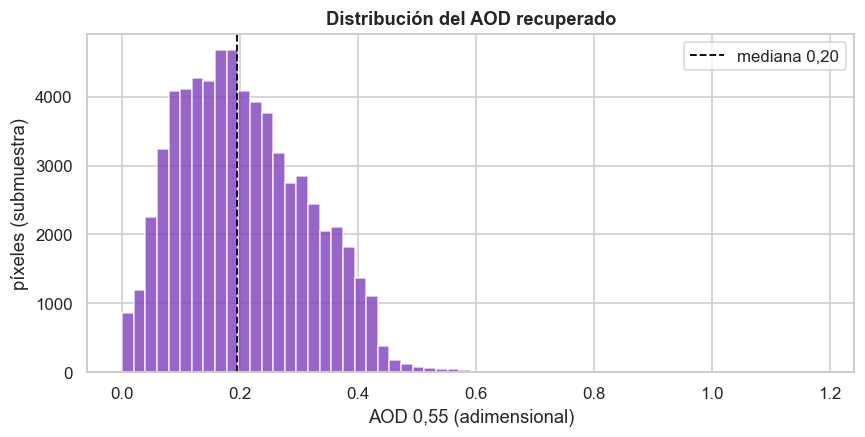

In [13]:
allv = np.concatenate(muestra_aod)
print(f"AOD mediano (mediana de medianas por escena): {fmt(esc.aod_mediana.median(), 3)}")
print(f"AOD máximo global:                            {fmt(esc.aod_max.max(), 3)}")
print(f"Escenas con algún AOD negativo:               {fmt(int((esc.aod_min < 0).sum()))}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(allv[(allv > -0.05) & (allv < 1.2)], bins=60, color="#7f3fbf", alpha=0.8)
ax.axvline(np.median(allv), color="black", ls="--", lw=1.2,
           label=f"mediana {fmt(np.median(allv), 2)}")
ax.set_xlabel("AOD 0,55 (adimensional)"); ax.set_ylabel("píxeles (submuestra)")
ax.set_title("Distribución del AOD recuperado")
ax.legend()
plt.show()

La distribución es la de un entorno urbano de carga moderada: una joroba centrada cerca de 0,2 y una cola hacia valores altos. La mediana cerca de 0,22 concuerda con lo que mide AERONET en Medellín, la estación de referencia más cercana, donde el AOD anual ronda 0,1 a 0,3 con picos por quema de biomasa entre febrero y abril. No hay AERONET en Cali ni en el Valle del Cauca, así que esta comparación es lo más cerca que se llega de una validación de suelo, y conviene anotarlo como una limitación honesta del análisis. La cola alta y el máximo cerca de 5,5 son consistentes con episodios puntuales de humo, probablemente de quema de caña.

## 7. El bache de comienzos de 2022

El equipo de calidad de MODIS reportó que un tramo del reprocesamiento de 2022 arrancó sin los coeficientes correctos, y que eso deja los valores de AOD del 1 de enero al 2 de julio de 2022 sesgados hacia abajo. El arreglo está planeado para una colección futura, así que los datos que tenemos todavía cargan ese sesgo. Para no creerlo a ciegas, comparamos el AOD medio de esos meses en 2022 contra los mismos meses de los otros cuatro años.

In [14]:
def media_ene_jul(df, anio):
    sub = df[(df.anio == anio) & (df.mes <= 6)]
    return sub["aod_media"].mean()

comparacion = {a: media_ene_jul(esc, a) for a in range(2020, 2025)}
otros = np.mean([v for a, v in comparacion.items() if a != 2022])
print("AOD medio de enero a junio por año:")
for a, v in comparacion.items():
    marca = "  <- periodo con sesgo reportado" if a == 2022 else ""
    print(f"  {a}: {fmt(v, 3)}{marca}")
print(f"\nMedia de los otros años: {fmt(otros, 3)}")
print(f"2022 queda {fmt(100 * (comparacion[2022] - otros) / otros, 1)}% respecto a esa media")

AOD medio de enero a junio por año:
  2020: 0,280
  2021: 0,273
  2022: 0,228  <- periodo con sesgo reportado
  2023: 0,217
  2024: 0,221

Media de los otros años: 0,248
2022 queda -8,2% respecto a esa media


El primer semestre de 2022 queda cerca de un 8% por debajo de la media de los demás años, en la dirección que el aviso oficial anticipaba, aunque la señal es modesta y se mezcla con una tendencia general a la baja del AOD entre 2020 y 2024. Como el sesgo reportado afecta la magnitud del AOD y no su disponibilidad, la cobertura de esos meses no se ve rara, pero por precaución conviene tratar esos valores aparte. La decisión defendible para las fases siguientes es marcar ese tramo con una bandera y, si se va a estudiar tendencia o a usar el AOD como objetivo, excluirlo en lugar de mezclarlo.

## 8. Que todo caiga en su sitio

Para cruzar MAIAC con los gases de Sentinel-5P, con la óptica de Sentinel-2 y con las estaciones, las escenas tienen que estar bien plantadas en el mapa y compartir un sistema de coordenadas conocido. Revisamos sobre una muestra de escenas que el sistema, el tamaño de celda y las dimensiones de la grilla sean uniformes.

In [15]:
muestra = [t for _, t in tifs[::200]]
info = []
for path in muestra:
    with rasterio.open(path) as src:
        info.append({"crs": str(src.crs), "res": round(src.res[0], 5),
                     "ancho": src.width, "alto": src.height})
dfg = pd.DataFrame(info)
print("Sistemas de coordenadas:", ", ".join(dfg.crs.unique()))
print("Tamaño de celda (grados):", ", ".join(fmt(x, 5) for x in sorted(dfg.res.unique())))
print("Grilla (ancho x alto):", ", ".join(f"{fmt(a)}x{fmt(h)}" for a, h in dfg[["ancho", "alto"]].drop_duplicates().itertuples(index=False)))
print(f"Tamaño de celda aproximado: {fmt(0.00898 * 111.32, 1)} km")

Sistemas de coordenadas: EPSG:4326
Tamaño de celda (grados): 0,00898
Grilla (ancho x alto): 134x224
Tamaño de celda aproximado: 1,0 km


Todas las escenas comparten el mismo sistema, EPSG:4326 (latitud y longitud en grados), con celdas de cerca de 0,009 grados, que a esta latitud son aproximadamente 1 kilómetro, y una grilla uniforme de 134 por 224 píxeles. La resolución gruesa es la nota importante para el cruce: cada píxel de MAIAC cubre cerca de un kilómetro, así que sobre el recuadro de Cali caben pocas celdas y una estación de DAGMA queda dentro de un solo píxel. Al emparejar con el dato de superficie hay que tener presente ese tamaño, porque el AOD de un píxel es un promedio de un kilómetro a la redonda, no un punto.

## Lo que nos llevamos

MAIAC aporta la única mirada de aerosoles del panel, pero llega con un hueco enorme y estructural. De los 1.827 días, 1.584 traen algún dato, y dentro de cada escena la cobertura de píxel es del orden del 9% sobre el Valle y del 17% sobre Cali, es decir entre el 83 y el 91% de nulos. Ese vacío es físico: MAIAC solo recupera AOD con cielo despejado, y el clima Af de Cali tiene nube casi todo el año, con las temporadas de lluvia hundiendo aún más la cobertura. El mapa de disponibilidad lo confirma al dibujar el valle del Cauca, con las cordilleras casi sin dato. El AOD que sí se recupera es sano (mediana cerca de 0,22, coherente con Medellín) y exigir Best Quality lo dejaría en cerca del 3%, así que el filtro correcto es quedarse con todos los píxeles despejados. Quedan tres cosas para las fases siguientes: el recuadro de Cali rinde mucho más que el rectángulo amplio del Valle y conviene trabajar sobre él; el primer semestre de 2022 carga un sesgo a la baja reportado y se debe marcar o excluir; y con una cobertura diaria tan baja, MAIAC no sirve como dato diario por píxel, sino agregado en el tiempo, por ejemplo a escala mensual, o rellenado con cuidado antes de alimentar el modelo.